In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [10]:
X=6*np.random.rand(100,1)-3
y=0.5 * X**2 +1.5*X + 2 + np.random.randn(100,1)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


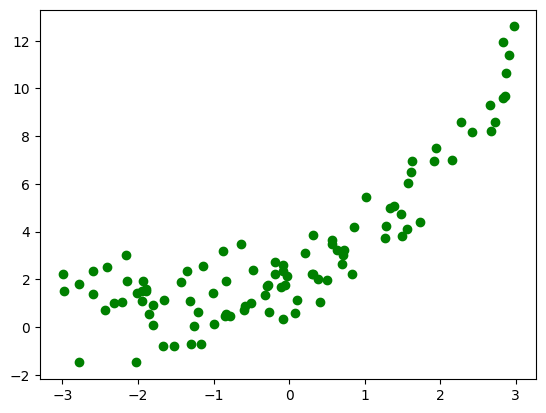

In [ ]:
plt.scatter(X,y,color="green" )


In [16]:
print(type(X),type(y))
pd.DataFrame(X ,columns=['X']).head()

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


,X
0,0.314184
1,-0.322225
2,-0.085066
3,-0.631390
4,-1.259303


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
from sklearn.metrics import r2_score,adjusted_rand_score
y_pred=regression.predict(X_test)
r2core=r2_score(y_test,y_pred)
print("R2 score is ",r2core)
adjr2score=1-(1-r2core)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Adjusted R2 score is ",adjr2score)

R2 score is  0.6258565116423891
Adjusted R2 score is  0.6050707622891884


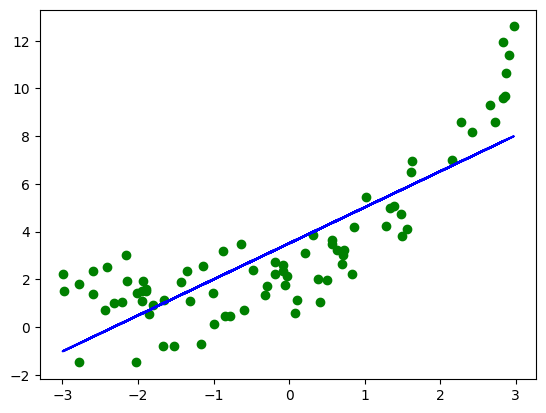

In [24]:
plt.scatter(X_train,y_train,color="green" )
plt.plot(X_train,regression.predict(X_train),color="blue")

## Apply polynomial regression

In [38]:
from sklearn.preprocessing import PolynomialFeatures
poly_features=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly_features.fit_transform(X_train)
print(X_train_poly)
X_test_poly=poly_features.transform(X_test)
print(X_test_poly)

[[ 1.00000000e+00 -1.52704733e+00  2.33187355e+00]
 [ 1.00000000e+00 -1.94292896e+00  3.77497295e+00]
 [ 1.00000000e+00 -1.86099383e-01  3.46329802e-02]
 [ 1.00000000e+00  5.65896449e-01  3.20238791e-01]
 [ 1.00000000e+00  1.50004420e+00  2.25013261e+00]
 [ 1.00000000e+00 -1.93555177e+00  3.74636067e+00]
 [ 1.00000000e+00 -2.59674453e+00  6.74308213e+00]
 [ 1.00000000e+00  1.01513085e+00  1.03049064e+00]
 [ 1.00000000e+00 -3.16247798e-02  1.00012670e-03]
 [ 1.00000000e+00  1.62558528e+00  2.64252752e+00]
 [ 1.00000000e+00 -2.41654689e+00  5.83969887e+00]
 [ 1.00000000e+00 -4.74191755e-01  2.24857820e-01]
 [ 1.00000000e+00 -1.80171319e+00  3.24617042e+00]
 [ 1.00000000e+00 -2.77469387e+00  7.69892606e+00]
 [ 1.00000000e+00  2.87558889e+00  8.26901145e+00]
 [ 1.00000000e+00 -8.53372090e-01  7.28243924e-01]
 [ 1.00000000e+00 -1.42714864e+00  2.03675324e+00]
 [ 1.00000000e+00 -5.90896828e-01  3.49159061e-01]
 [ 1.00000000e+00  7.30176219e-01  5.33157310e-01]
 [ 1.00000000e+00 -1.31101481e+

In [39]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
new_predictions=regression.predict(X_test_poly)
score=r2_score(y_test,new_predictions)
print("R2 score is ",score)
adjustedr2score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test_poly.shape[1]-1)
print("Adjusted R2 score is ",adjustedr2score)

R2 score is  0.882980819720927
Adjusted R2 score is  0.8610397234186008


In [31]:
print(regression.coef_)
print(regression.intercept_)


[[0.         1.50529258 0.49567155]]
[2.04487099]


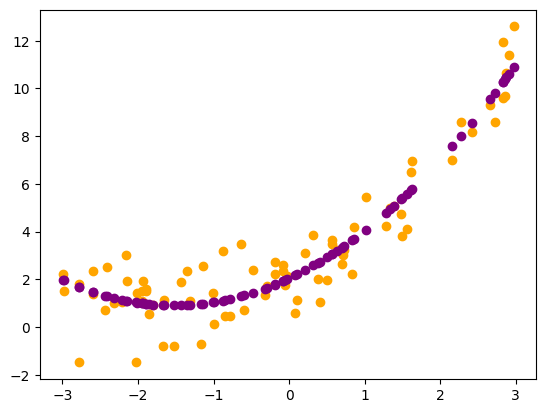

In [34]:
plt.scatter(X_train,y_train,color="orange" )
plt.scatter(X_train,regression.predict(X_train_poly),color="purple")

## Increased the degree to 3
let's see what happens(r2 score)

R2 score is  0.8665663548206651


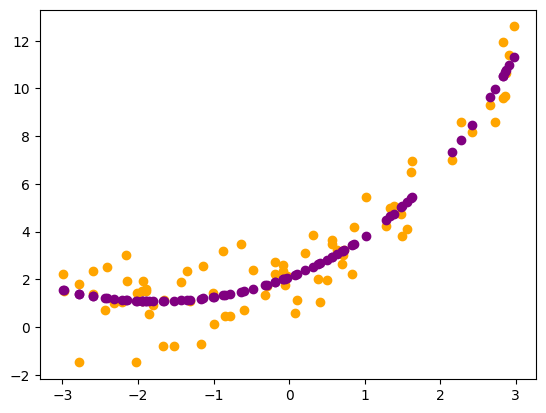

In [53]:
from sklearn.preprocessing import PolynomialFeatures
poly_features=PolynomialFeatures(degree=4,include_bias=True)
X_train_poly3=poly_features.fit_transform(X_train)
# print(X_train_poly3)
X_test_poly3=poly_features.transform(X_test)
# print(X_test_poly3)
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_poly3,y_train)
new_predictions=regression.predict(X_test_poly3)
score=r2_score(y_test,new_predictions)
print("R2 score is ",score)
# adjustedr2score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test_poly3.shape[1]-1)
# print("Adjusted R2 score is ",adjustedr2score)
plt.scatter(X_train,y_train,color="orange" )
plt.scatter(X_train,regression.predict(X_train_poly3),color="purple")

## Predicting new data

using degree=2

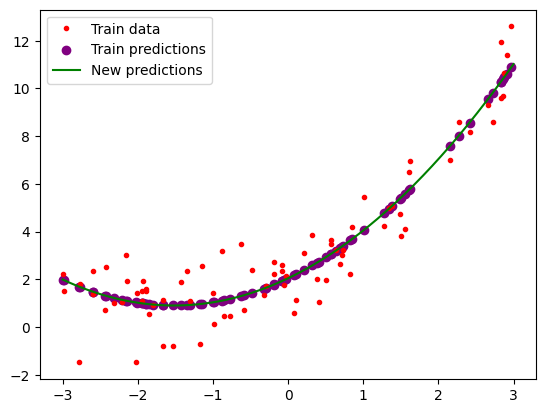

In [48]:
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly_features.transform(X_new)
predicted_new=regression.predict(X_new_poly)
# print("X :",X_new,"\nPredicted Y :",predicted_new)
plt.plot(X_train,y_train,"r." ,label="Train data")
plt.scatter(X_train,regression.predict(X_train_poly),color="purple",label="Train predictions")
plt.plot(X_new,predicted_new,color="green", label="New predictions")
plt.legend()
plt.show()

## Pipelining

In [56]:
from sklearn.pipeline import Pipeline

In [57]:
def poly_regression(degree):
    X_new=np.linspace(-3,3,200).reshape(200,1)

    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    regression=LinearRegression()

    pipeline=Pipeline([("poly_features",poly_features),("regression",regression)])

    pipeline.fit(X_train,y_train)
    new_predictions=pipeline.predict(X_new)
    plt.plot(X_new, new_predictions,'r',label=f"Degree {degree}",linewidth=3)
    plt.plot(X_train,y_train,"b.",linewidth=3)
    plt.plot(X_test,y_test,"g.",linewidth=3)
    plt.legend()
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4,0,10])
    plt.show()
    


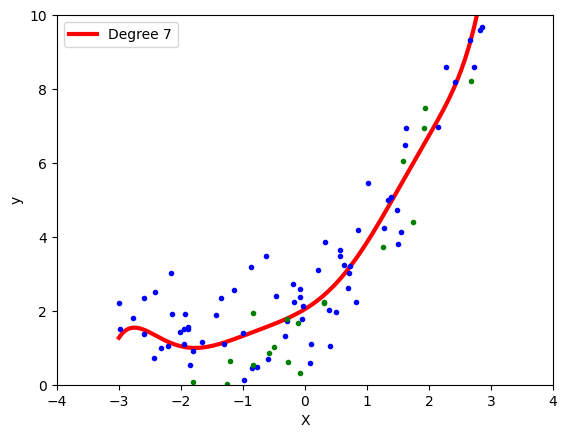

In [67]:
poly_regression(7)